# 第7章: 機械学習

本章では、[Stanford Sentiment Treebank (SST)](https://nlp.stanford.edu/sentiment/) データセットを用い、評判分析器（ポジネガ分類器）を構築する。ここでは処理を簡略化するため、[General Language Understanding Evaluation (GLUE)](https://gluebenchmark.com/) ベンチマークで配布されているSSTデータセットを用いる。


## 60. データの入手・整形

GLUEのウェブサイトから[SST-2](https://dl.fbaipublicfiles.com/glue/data/SST-2.zip)データセットを取得せよ。学習データ（`train.tsv`）と検証データ（`dev.tsv`）のぞれぞれについて、ポジティブ (1) とネガティブ (0) の事例数をカウントせよ。

In [ ]:
import requests
import zipfile
import io
import os
import pandas as pd

url = "https://dl.fbaipublicfiles.com/glue/data/SST-2.zip"

zip_file_name = "SST-2.zip"

data_dir = "SST-2"

if not os.path.exists(data_dir):
    os.makedirs(data_dir)

print(f"Downloading {zip_file_name}...")
response = requests.get(url)

if response.status_code == 200:
    # zipファイルをメモリ上で展開
    with zipfile.ZipFile(io.BytesIO(response.content)) as zf:
        # 全てのファイルを指定したディレクトリに展開
        zf.extractall(data_dir)
    print(f"{zip_file_name} downloaded and extracted to {data_dir}/")
else:
    print(f"Failed to download the file. Status code: {response.status_code}")

SST-2.zip downloaded and extracted to SST-2/


In [ ]:
import os

data_dir = "SST-2"

# SST-2ディレクトリのコンテンツをリスト表示
print(f"Contents of {data_dir}/:")
for root, dirs, files in os.walk(data_dir):
    level = root.replace(data_dir, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 4 * (level + 1)
    for f in files:
        print(f'{subindent}{f}')

Contents of SST-2/:
SST-2/
    SST-2/
        dev.tsv
        test.tsv
        train.tsv
        original/
            sentiment_labels.txt
            datasetSentences.txt
            dictionary.txt
            STree.txt
            datasetSplit.txt
            README.txt
            SOStr.txt
            original_rt_snippets.txt


In [ ]:
import pandas as pd
import os

data_dir = os.path.join("SST-2", "SST-2")

# train.tsv の読み込みとカウント
train_path = os.path.join(data_dir, "train.tsv")
train_df = pd.read_csv(train_path, sep='\t')
print("Train data label counts:")
print(train_df['label'].value_counts())

# dev.tsv の読み込みとカウント
dev_path = os.path.join(data_dir, "dev.tsv")
dev_df = pd.read_csv(dev_path, sep='\t')
print("\nDev data label counts:")
print(dev_df['label'].value_counts())

Train data label counts:
label
1    37569
0    29780
Name: count, dtype: int64

Dev data label counts:
label
1    444
0    428
Name: count, dtype: int64


## 61. 特徴ベクトル

Bag of Words (BoW) に基づき、学習データ（`train.tsv`）および検証データ（`dev.tsv`）のテキストを特徴ベクトルに変換したい。ここで、ある事例のテキストの特徴ベクトルは、テキスト中に含まれる単語（スペース区切りのトークン）の出現頻度で構成する。例えば、"too loud , too goofy"というテキストに対応する特徴ベクトルは、以下のような辞書オブジェクトで表現される。

```python
{'too': 2, 'loud': 1, ',': 1, 'goofy': 1}
```

各事例はテキスト、特徴ベクトル、ラベルを格納した辞書オブジェクトでまとめておく。例えば、先ほどの"too loud , too goofy"に対してラベル"0"（ネガティブ）が付与された事例は、以下のオブジェクトで表現される。

```python
{'text': 'too loud , too goofy', 'label': '0', 'feature': {'too': 2, 'loud': 1, ',': 1, 'goofy': 1}}
```

学習データと検証データの各事例を上記のような辞書オブジェクトに変換したうえで、学習データと検証データのそれぞれを、辞書オブジェクトのリストとして表現せよ。さらに、学習データの最初の事例について、正しく特徴ベクトルに変換できたか、目視で確認せよ。

In [ ]:
import pandas as pd
import os

data_dir = os.path.join("SST-2", "SST-2")

# train.tsv の処理
train_path = os.path.join(data_dir, "train.tsv")
train_df = pd.read_csv(train_path, sep='\t')

train_features = []
for index, row in train_df.iterrows():
    text = row['sentence']
    label = row['label']
    feature = {}
    for token in text.split():
        if token in feature:
            feature[token] += 1
        else:
            feature[token] = 1
    train_features.append({'text': text, 'label': label, 'feature': feature})

# リストからDataFrameを再構築（または新しい列を追加）
train_processed_df = pd.DataFrame(train_features)

print("Train data (first example with feature vector):")
print(train_processed_df.iloc[0]) # Modified from train_processed_df[0]


# dev.tsv の処理
dev_path = os.path.join(data_dir, "dev.tsv")
dev_df = pd.read_csv(dev_path, sep='\t')

dev_features = []
for index, row in dev_df.iterrows():
    text = row['sentence']
    label = row['label']
    feature = {}
    for token in text.split():
        if token in feature:
            feature[token] += 1
        else:
            feature[token] = 1
    dev_features.append({'text': text, 'label': label, 'feature': feature})

# リストからDataFrameを再構築（または新しい列を追加）
dev_processed_df = pd.DataFrame(dev_features)

print("\nDev data (first example with feature vector):")
print(dev_processed_df.iloc[0])

Train data (first example with feature vector):
text            hide new secretions from the parental units 
label                                                      0
feature    {'hide': 1, 'new': 1, 'secretions': 1, 'from':...
Name: 0, dtype: object

Dev data (first example with feature vector):
text         it 's a charming and often affecting journey . 
label                                                      1
feature    {'it': 1, ''s': 1, 'a': 1, 'charming': 1, 'and...
Name: 0, dtype: object


## 62. 学習

61で構築した学習データの特徴ベクトルを用いて、ロジスティック回帰モデルを学習せよ。

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction import DictVectorizer
import numpy as np

X_train_features = [d['feature'] for d in train_features]
y_train = np.array([d['label'] for d in train_features])

vectorizer = DictVectorizer()
X_train = vectorizer.fit_transform(X_train_features)

model = LogisticRegression(solver = 'liblinear')
model.fit(X_train, y_train)

print("ロジスティック回帰モデルの学習が完了しました。")

ロジスティック回帰モデルの学習が完了しました。


## 63. 予測

学習したロジスティック回帰モデルを用い、検証データの先頭の事例のラベル（ポジネガ）を予測せよ。また、予測されたラベルが検証データで付与されていたラベルと一致しているか、確認せよ。

In [ ]:
from sklearn.feature_extraction import DictVectorizer
import numpy as np

# 検証データの最初の事例を取得
first_dev_example = dev_features[0]
original_text = first_dev_example['text']
original_label = first_dev_example['label']
first_dev_feature = [first_dev_example['feature']]

# DictVectorizerで特徴ベクトルを変換
X_dev_first = vectorizer.transform(first_dev_feature)

# 予測
predicted_label = model.predict(X_dev_first)[0]

print(f"検証データの最初の事例のテキスト: '{original_text}'")
print(f"検証データの最初の事例の元のラベル: {original_label}")
print(f"予測されたラベル: {predicted_label}")

if predicted_label == original_label:
    print("予測されたラベルは元のラベルと一致しています。")
else:
    print("予測されたラベルは元のラベルと一致していません。")

検証データの最初の事例のテキスト: 'it 's a charming and often affecting journey . '
検証データの最初の事例の元のラベル: 1
予測されたラベル: 1
予測されたラベルは元のラベルと一致しています。


## 64. 条件付き確率

学習したロジスティック回帰モデルを用い、検証データの先頭の事例を各ラベル（ポジネガ）に分類するときの条件付き確率を求めよ。

In [ ]:
# 条件付き確率の取得
probabilities = model.predict_proba(X_dev_first)[0]

# クラスラベルと対応する確率を表示
print(f"検証データの最初の事例のテキスト: '{original_text}'")
print(f"検証データの最初の事例の元のラベル: {original_label}")
print("各クラスへの条件付き確率:")
for i, prob in enumerate(probabilities):
    print(f"  クラス {model.classes_[i]}: {prob:.4f}")

検証データの最初の事例のテキスト: 'it 's a charming and often affecting journey . '
検証データの最初の事例の元のラベル: 1
各クラスへの条件付き確率:
  クラス 0: 0.0042
  クラス 1: 0.9958


## 65. テキストのポジネガの予測

与えられたテキストのポジネガを予測するプログラムを実装せよ。例えば、テキストとして"the worst movie I 've ever seen"を与え、ロジスティック回帰モデルの予測結果を確認せよ。


In [ ]:
def predict_sentiment(text, model, vectorizer):
  feature = {}
  for token in text.split():
      if token in feature:
          feature[token] += 1
      else:
          feature[token] = 1

  X_predict = vectorizer.transform([feature])

  probabilities = model.predict_proba(X_predict)[0]

  print(f"テキスト: '{text}'")
  print("各クラスへの条件付き確率:")
  for i, prob in enumerate(probabilities):
    print(f"  クラス {model.classes_[i]}: {prob:.4f}")

  predicted_label = model.predict(X_predict)[0]
  print(f"予測されたラベル: {predicted_label}")

In [ ]:
text = "the worst movie I've ever seen"

predict_sentiment(text, model, vectorizer)

テキスト: 'the worst movie I've ever seen'
各クラスへの条件付き確率:
  クラス 0: 0.9661
  クラス 1: 0.0339
予測されたラベル: 0


## 66. 混同行列の作成

学習したロジスティック回帰モデルの検証データにおける混同行列（confusion matrix）を求めよ。

In [ ]:
from sklearn.metrics import confusion_matrix

# 検証データの特徴ベクトルとラベルを準備
X_dev_features = [d['feature'] for d in dev_features]
y_dev = np.array([d['label'] for d in dev_features])

# 特徴ベクトルを数値データに変換
X_dev = vectorizer.transform(X_dev_features)

# 予測
y_pred = model.predict(X_dev)

cm = confusion_matrix(y_dev, y_pred)
print("混同行列:")
print(cm)

混同行列:
[[334  94]
 [ 71 373]]


## 67. 精度の計測

学習したロジスティック回帰モデルの正解率、適合率、再現率、F1スコアを、学習データおよび検証データ上で計測せよ。

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_dev, y_pred)
precision = precision_score(y_dev, y_pred)
recall = recall_score(y_dev, y_pred)
f1 = f1_score(y_dev, y_pred)

print("検証データでの評価:")
print(f"  正解率 (Accuracy): {accuracy:.4f}")
print(f"  適合率 (Precision): {precision:.4f}")
print(f"  再現率 (Recall): {recall:.4f}")
print(f"  F1スコア (F1-score): {f1:.4f}")

検証データでの評価:
  正解率 (Accuracy): 0.8108
  適合率 (Precision): 0.7987
  再現率 (Recall): 0.8401
  F1スコア (F1-score): 0.8189


## 68. 特徴量の重みの確認

学習したロジスティック回帰モデルの中で、重みの高い特徴量トップ20と、重みの低い特徴量トップ20を確認せよ。

In [ ]:
# ロジスティック回帰モデルからクラス0の係数（重み）を取得
coef = model.coef_[0]

# DictVectorizerの語彙（単語とインデックスのマッピング）を取得
vocabulary = vectorizer.vocabulary_

# 単語と係数をペアにする
word_coef = {word: coef[idx] for word, idx in vocabulary.items()}

# 重みの高い順にソート
sorted_word_coef = sorted(word_coef.items(), key=lambda x: x[1], reverse=True)

print("重みの高い特徴量トップ20:")
for word, weight in sorted_word_coef[:20]:
    print(f"  {word}: {weight:.4f}")

print("\n重みの低い特徴量トップ20:")
for word, weight in sorted_word_coef[-20:]:
    print(f"  {word}: {weight:.4f}")

重みの高い特徴量トップ20:
  refreshing: 3.4798
  remarkable: 3.4740
  powerful: 3.2547
  hilarious: 3.1916
  beautiful: 3.0083
  wonderful: 2.9951
  prose: 2.9325
  terrific: 2.9240
  treat: 2.8799
  appealing: 2.8640
  enjoyable: 2.8297
  charmer: 2.7813
  vividly: 2.7234
  likable: 2.7057
  solid: 2.6377
  charming: 2.6361
  impressive: 2.6157
  half-bad: 2.5875
  fascinating: 2.5872
  intriguing: 2.5580

重みの低い特徴量トップ20:
  unfortunately: -2.9689
  pointless: -3.0063
  poor: -3.0134
  lousy: -3.0141
  hardly: -3.0192
  none: -3.0241
  squanders: -3.0506
  lack: -3.0788
  waste: -3.1931
  loses: -3.2167
  depressing: -3.2174
  flat: -3.2291
  bore: -3.3023
  stupid: -3.3733
  failure: -3.6440
  mess: -3.6980
  devoid: -3.7064
  worst: -4.0191
  lacks: -4.0883
  lacking: -4.3574


## 69. 正則化パラメータの変更

ロジスティック回帰モデルを学習するとき、正則化の係数（ハイパーパラメータ）を調整することで、学習時の適合度合いを制御できる。正則化の係数を変化させながらロジスティック回帰モデルを学習し、検証データ上の正解率を求めよ。実験の結果は、正則化パラメータを横軸、正解率を縦軸としたグラフにまとめよ。

C=0.001: 検証データ正解率 = 0.6846
C=0.010: 検証データ正解率 = 0.7557
C=0.100: 検証データ正解率 = 0.8005
C=1.000: 検証データ正解率 = 0.8108
C=10.000: 検証データ正解率 = 0.8245
C=100.000: 検証データ正解率 = 0.7947
C=1000.000: 検証データ正解率 = 0.7775


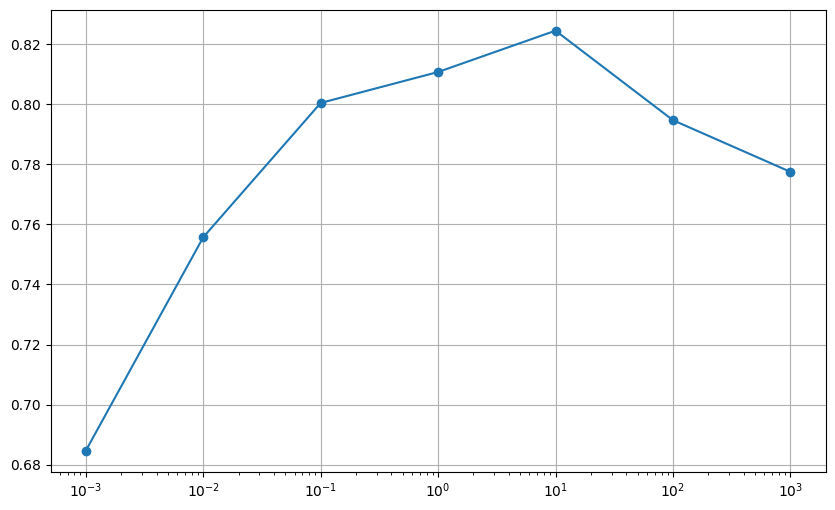

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

C_values = np.logspace(-3, 3, 7) # 0.001, 0.01, 0.1, 1, 10, 100, 1000

accuracies = []

for C in C_values:
    # ロジスティック回帰モデルの学習
    model_reg = LogisticRegression(solver='liblinear', C=C)
    model_reg.fit(X_train, y_train)

    # 検証データでの予測
    y_pred_reg = model_reg.predict(X_dev)

    # 正解率の計算
    accuracy_reg = accuracy_score(y_dev, y_pred_reg)
    accuracies.append(accuracy_reg)

    print(f"C={C:.3f}: 検証データ正解率 = {accuracy_reg:.4f}")

# 結果の可視化
plt.figure(figsize=(10, 6))
plt.plot(C_values, accuracies, marker='o')
plt.xscale('log')
plt.grid(True)
plt.show()